LISTA 7 - APRENDIZADO NÃO SUPERVISIONADO

<b>QUESTÃO 1 -</b> Exploração dos dados<br>
• Exiba as 5 primeiras linhas do dataset<br>
• Mostre estatísticas descritivas<br>
• Verifique valores nulos<br>
O dataset precisa de limpeza? Justifique.

In [522]:
from sklearn.datasets import load_wine
import pandas as pd

dataset = load_wine()

df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
target = "class"
df[target] = dataset.target
display(df.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [523]:
display(df.describe())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [524]:
display(df.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
class                           0
dtype: int64

<b>RESPOSTA:</b> Pode-se observar que o dataset não possui valores nulos, portanto não precisa de limpeza.

<b>QUESTÃO 2 -</b> Visualização inicial<br>
Crie um gráfico de dispersão utilizando duas variáveis (ex: comprimento e largura da pétala). Colora os pontos usando os rótulos reais.<br>
Os dados parecem separáveis visualmente?

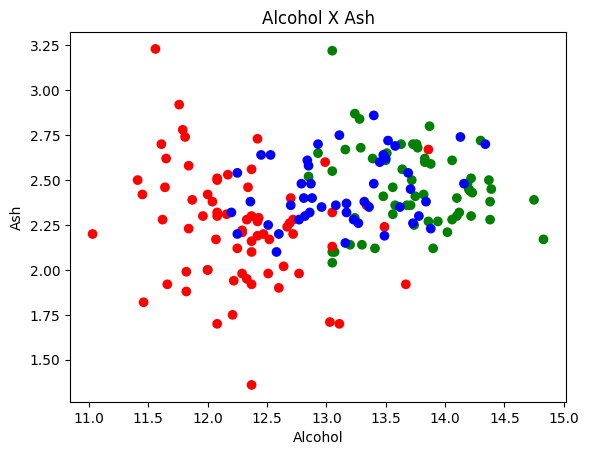

In [525]:
import matplotlib.pyplot as plt

classificacao_cores = {
    0: "green",
    1: "red",
    2: "blue"
}

cores = df[target].map(classificacao_cores)

plt.scatter(df["alcohol"], df["ash"], c=cores)

plt.title('Alcohol X Ash')
plt.xlabel('Alcohol')
plt.ylabel('Ash')

plt.show()


As variáveis não parecem ser muito bem separáveis, com dados muito misturados

<b>QUESTÃO 3 -</b> 3. Aplicando K-Means<br>
Compare os clusters encontrados com os rótulos reais.

In [526]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

X = df[dataset.feature_names]
labels = kmeans.fit_predict(X)

In [527]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(labels_true=df[target], labels_pred=labels)
print(f"Adjusted rand index: {ari}")

Adjusted rand index: 0.3517721516862617


O Adjusted Rand Index(ARI) ter um valor de 0.35 indica que o modelo não tem um comportamente aleatório mas que ainda está longe dos rótulos reais

<b>QUESTÃO 4 -</b> Método do Cotovelo <br>
Calcule a inércia para valores de K de 1 a 10 e plote o gráfico.<br>
Qual o melhor valor de K?

In [528]:
valores_inercia = []
valores_k = [i for i in range(1,11)]

for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X)
    print(f'Inércia com k={k}: {kmeans.inertia_}')
    valores_inercia.append(kmeans.inertia_)

Inércia com k=1: 17592296.38350847
Inércia com k=2: 4543749.614531861
Inércia com k=3: 2633555.332409339
Inércia com k=4: 1351749.3691428083
Inércia com k=5: 965019.0873703662
Inércia com k=6: 684050.7480527543
Inércia com k=7: 414997.5629249221
Inércia com k=8: 347293.48953935824
Inércia com k=9: 290111.64183758595
Inércia com k=10: 237728.9703008799


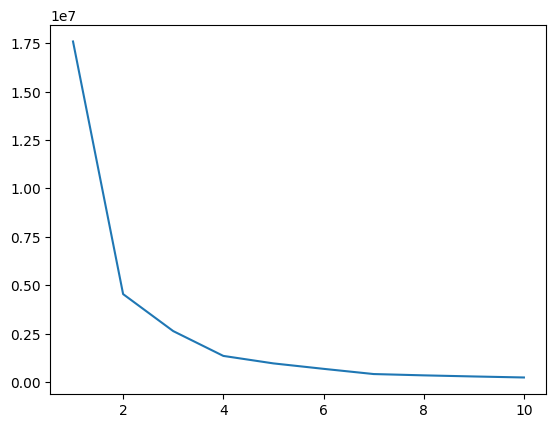

In [529]:
plt.plot(valores_k, valores_inercia)
plt.show()

Analisando o gráfico, o melhor valor de seria K=3, pois é o equilíbrio entre um K não muito grande e uma inércia estabilizada.

<b>QUESTÃO 5 -</b> Silhouette Score <br>
Calcule o Silhouette Score para valores de K entre 2 e 10.<br>
Qual o melhor valor de K?

In [530]:
from sklearn.metrics import silhouette_score

valores_k = [i for i in range(2,11)]
valores_silhouette_score = []

for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    valores_silhouette_score.append(silhouette_score(X, labels))

print(valores_silhouette_score)

[0.6568536504294317, 0.5595823478987213, 0.566947772359962, 0.5081797474674721, 0.5421550993884962, 0.5594856546979965, 0.5288559452839446, 0.5052248272657786, 0.5106480753751393]


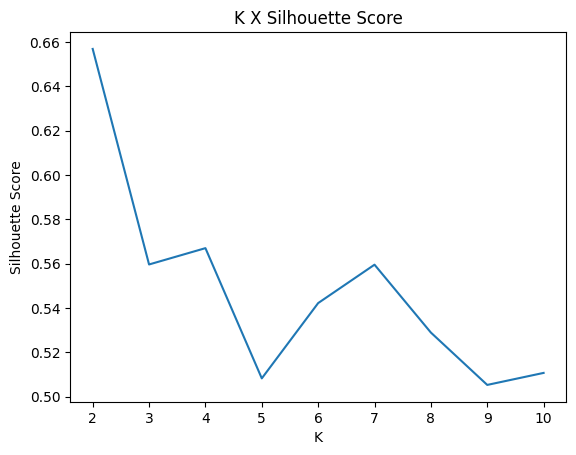

In [531]:
plt.plot(valores_k, valores_silhouette_score)
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("K X Silhouette Score")

plt.show()

Observando o gráfico, podemos observar que o melhor para K=3, já que é o ponto com maior silhouette score.

<b>QUESTÃO 6 -</b> Padronização dos dados<br>
Aplique novamente o K-Means.<br>
Houve mudança nos clusters? Explique.

In [532]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)
df[dataset.feature_names] = X.copy()

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

ari = adjusted_rand_score(df[target], labels)
print(f"Adjusted rand index: {ari}")



Adjusted rand index: 0.8974949815093207


Após a normalização, ficou nítida a melhoria de desemepnho do KMeans, que saiu de um Adjusted Rand Index de 0.35 para 0.89. Isso aconteceu porque a normalização impediu que variáveis com altos valores dominassem as previsões do modelo.

<b>QUESTÃO 7 -</b> Aplicando PCA<br>
Plote os dados transformados.<br>
A separação melhorou?<br>

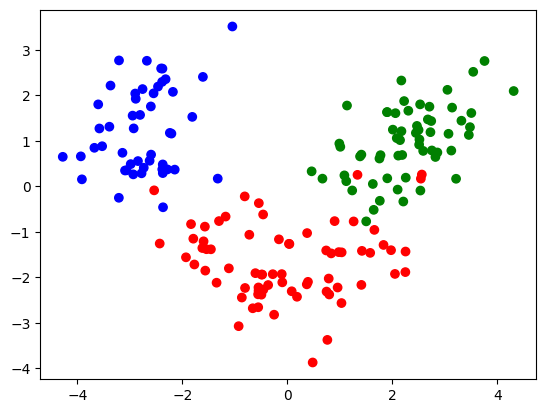

In [533]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

y = []
x = []

for i in X_pca:
    x.append(i[0])
    y.append(i[1])

plt.scatter(x,y, c=cores)
plt.show()

A separação melhorou muito com o uso do PCA, agora temos poucos pontos fora do seu grupo.

<b>QUESTÃO 8 -</b> Variância explicada<br>
Analise: <br>
Quanto da variância foi preservada? Isso é suficiente?

In [534]:
variancias = pca.explained_variance_ratio_

print(f"Variâncias: {variancias}")
print(f"Total da variância preservada: {variancias.sum()}")

Variâncias: [0.36198848 0.1920749 ]
Total da variância preservada: 0.5540633835693526


55% da variância foi preservada, o que significa que o PCA retirou quase metade da variância dos dados do modelo,o que é uma quantidade alta e que pode prejudicar a interpretação real dos dados e resultados.

<b>QUESTÃO 9 -</b> K-Means após PCA<br>
Aplique K-Means nos dados reduzidos.<br>
Compare os resultados com os obtidos anteriormente.

In [535]:
import numpy as np
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_pca)

ari = adjusted_rand_score(labels_true=df[target], labels_pred=labels)
print(f"Adjusted rand index: {ari}")

Adjusted rand index: 0.8961671105205941


O Adjusted Rand Index das previsões do modelo utilizando os dados alterados pelo PCA foi ligeiramente menor que o obtido após a normalização dos dados originais. Isso pode ser explicado pelo resultado obtido na questão 8, que mostrou que os dados gerados pelo PCA perderam quase metade da variância dos dados originais, atrapalhando o modelo a distinguir classes que com dimensões extras eram mais previsíveis. Entretanto, a diferença é muito pequena e utilizar o PCA tende a agilizar o processo de treinamento do modelo por conta da redução de dimensionalidade, portanto, é uma opção a ser considerada.

<b>QUESTÃO 10 -</b> Responda: <br>
• Quando usar PCA antes do K-Means? <br>
• Quais as vantagens?<br>
• Quando isso pode prejudicar o modelo?

<em>Quando usar PCA antes do K-Means?</em>

Existem 3 motivos principais para a a utilização do PCA:<br>
1 - Redução da dimensionalidade<br>
2 - Eliminar variáveis correlacionadas<br>
3 - Gerar visualizações mais simples(2D)

<em>Quais as vantagens?</em>

As principais vantagens de se utilizar o PCA são: <br>
1 - Menor custo computacional e eliminação de ruído graças à redução de dimensionalidade<br>
2 - Pode melhorar a separação dos clusters e ajudar nas visualizações

<em>Quando isso pode prejudicar o modelo?</em>
Quando aplicar o PCA retira informações importantes do conjunto de dados